Image fusion - Notebook 5.2

Importiamo le librerie necessarie per la simulazione

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pydicom import dcmread

Leggiamo due immagini DICOM e le convertiamo a 8 bit con la libreria opencv

In [2]:
image1=dcmread("../data/REF.dcm")
image2=dcmread("../data/FLT.dcm")
A=cv2.normalize(image1.pixel_array, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
B=cv2.normalize(image2.pixel_array, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

Visualizziamo le due immagini, sono due immagini di un fantoccio TAC con due orientazioni diverse

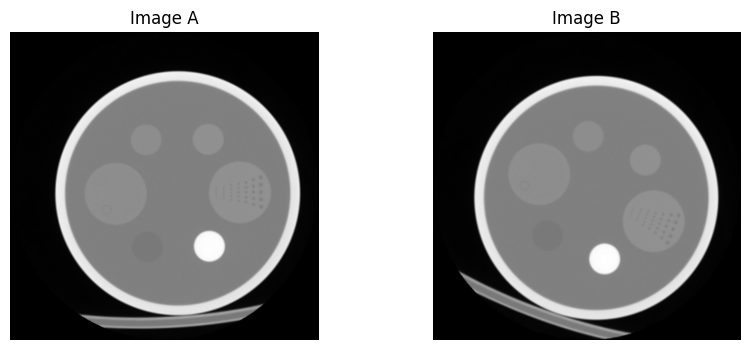

In [3]:
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 2, 1)
axs1 = fig.add_subplot(1, 2, 2)
imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Image B",fontsize=12)
axs1.set_axis_off()

Applichiamo il metodo RGB creando uan immagine a tre canali dalle due immagini da fondere

In [4]:
# RGB method
A3 = np.stack([A, np.zeros([A.shape[0],A.shape[1]]), A], axis = -1)  # pink
B3 = np.stack([np.zeros([B.shape[0],B.shape[1]]), B, np.zeros([B.shape[0],B.shape[1]])], axis = -1)  # green
RGB = np.stack([A, B, A], axis = -1)  # create fused image

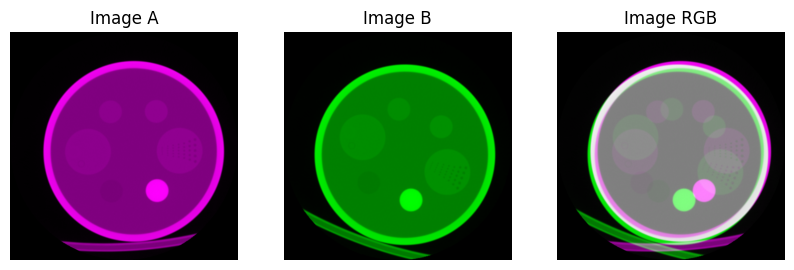

In [5]:
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3)
imgplot = axs0.imshow(A3)
axs0.set_title("Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B3)
axs1.set_title("Image B",fontsize=12)
axs1.set_axis_off()
imgplot = axs2.imshow(RGB)
axs2.set_title("Image RGB",fontsize=12)
axs2.set_axis_off()

Vediamo il risultato dell'image fusion

Realizziamo il blending con le librerie opencv

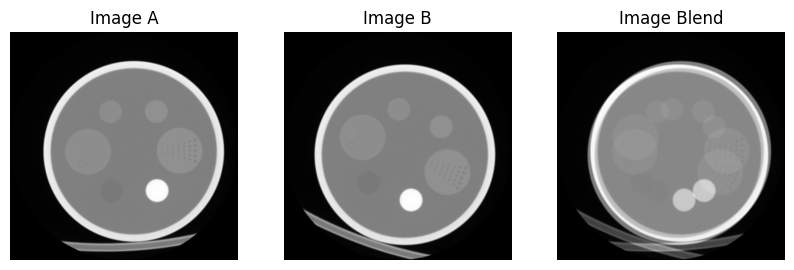

In [6]:
# blending method
alfa=0.5
Blend = cv2.addWeighted(A, alfa, B, 1-alfa, 0) 
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3)
imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Image B",fontsize=12)
axs1.set_axis_off()
imgplot = axs2.imshow(Blend,cmap='gray')
axs2.set_title("Image Blend",fontsize=12)
axs2.set_axis_off()

In [ ]:
fig, ax = plt.subplots(1,11)
alfaValues=np.linspace(0,1,11)
for i in range(11):
    Blend = cv2.addWeighted(A, alfaValues[i], B, 1-alfaValues[i], 0) 
    imgplot = ax[i].imshow(Blend,cmap='gray')
    input("Press Enter to continue...")